In [1]:
import pandas as pd
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

from sklearn.model_selection import train_test_split


# import metrics MRL
from sklearn.metrics import accuracy_score, r2_score,confusion_matrix, classification_report




In [2]:

###################
# oil production #
###################
prod_Petroleo=pd.read_csv(r"C:\Users\Usuario\Documents\UPA_Extension\Produccion_Petroleo_m3.csv",sep=',')
Prod_Pet=pd.DataFrame(prod_Petroleo)
Prod_Pet

,anio,mes,concepto,cuenca,provincia,empresa,Petróleo(m3)
0,2025,12,Shale Oil,NEUQUINA,Neuquén,YPF S.A.,1616623.09
1,2025,11,Shale Oil,NEUQUINA,Neuquén,YPF S.A.,1497664.71
2,2025,10,Shale Oil,NEUQUINA,Neuquén,YPF S.A.,1494208.17
3,2025,9,Shale Oil,NEUQUINA,Neuquén,YPF S.A.,1386774.63
4,2025,8,Shale Oil,NEUQUINA,Neuquén,YPF S.A.,1382318.37
...,...,...,...,...,...,...,...
72316,2016,7,Producción convencional,NORESTE,Jujuy,PETRO AP S.A.,0.00
72317,2016,10,Shale Oil,NEUQUINA,Rio Negro,KILWER S.A.,0.00
72318,2013,5,Tight_oil,NEUQUINA,Mendoza,SAN JORGE PETROLEUM S.A.,0.00
72319,2017,12,Producción convencional,ÑIRIHUAU,Chubut,KILWER S.A.,0.00


In [3]:

promedio_Prod_Pet = Prod_Pet.groupby('anio')['Petróleo(m3)'].mean().dropna()
print(promedio_Prod_Pet)

anio
2009     8727.418546
2010     8610.080030
2011     7592.405659
2012     7118.370236
2013     6447.249599
2014     5961.110332
2015     6401.439897
2016     6244.198561
2017     6076.247969
2018     6561.467447
2019     7377.975130
2020     7095.950637
2021     7784.465479
2022     8912.418158
2023     9752.360396
2024    11164.059858
2025    12132.578668
Name: Petróleo(m3), dtype: float64


In [4]:
ppp=pd.DataFrame({'anio':promedio_Prod_Pet.index,'Petroleo(m3)': promedio_Prod_Pet}).reset_index(drop=True)
ppp

,anio,Petroleo(m3)
0,2009,8727.418546
1,2010,8610.080030
2,2011,7592.405659
3,2012,7118.370236
4,2013,6447.249599
5,2014,5961.110332
6,2015,6401.439897
7,2016,6244.198561
8,2017,6076.247969
9,2018,6561.467447


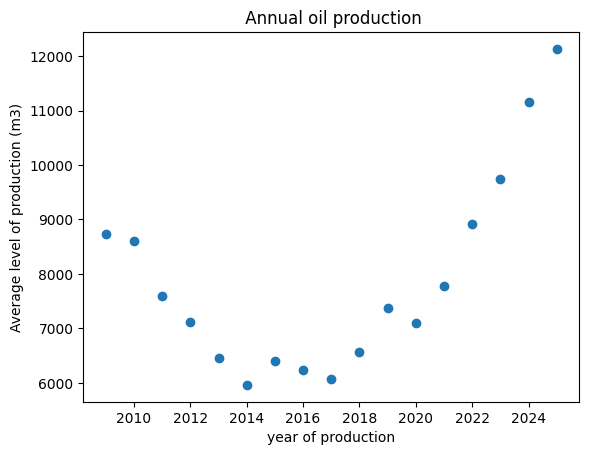

In [5]:

x_pet=np.array(ppp['anio'] ,dtype=float)    
y_pet=np.array(ppp['Petroleo(m3)'] ,dtype=float)
plt.scatter(x_pet,y_pet)
plt.ylabel('Average level of production (m3)')
plt.xlabel('year of production')
plt.title(' Annual oil production')
plt.show()

In [6]:

mean=ppp['Petroleo(m3)'].mean()
mean
# 7377.975130039624

np.float64(7879.98803543309)

In [43]:

mean=ppp['Petroleo(m3)'].mean()
mean
# 7377.975130039624
ppp['Prod_Sup'] = np.where(ppp['Petroleo(m3)']>mean, 1, 0)
ppp['Prod_Sup'].value_counts()


Prod_Sup
0    11
1     6
Name: count, dtype: int64

In [44]:
ppp

,anio,Petroleo(m3),Prod_Sup
0,2009,8727.418546,1
1,2010,8610.080030,1
2,2011,7592.405659,0
3,2012,7118.370236,0
4,2013,6447.249599,0
5,2014,5961.110332,0
6,2015,6401.439897,0
7,2016,6244.198561,0
8,2017,6076.247969,0
9,2018,6561.467447,0


In [45]:
x_pet=pd.DataFrame(ppp,columns=['Petroleo(m3)'] ,dtype=int)    
y_pet=pd.DataFrame(ppp,columns=['Prod_Sup'] ,dtype=int)

x_train_rp,x_test_rp,y_train_rp,y_test_rp=train_test_split(x_pet,y_pet,test_size=0.3, random_state=123)
y_test_rp

,Prod_Sup
4,0
9,0
16,1
8,0
5,0
7,0


In [61]:

print("x_train shape:",x_train_rp.shape)
print("y_train shape:",y_train_rp.shape)
print("x_test shape:",x_test_rp.shape)
print("y_test shape:",y_test_rp.shape)

x_train_rp

x_train shape: (11, 1)
y_train shape: (11, 1)
x_test shape: (6, 1)
y_test shape: (6, 1)


,Petroleo(m3)
0,8727
10,7377
11,7095
3,7118
1,8610
6,6401
15,11164
12,7784
2,7592
14,9752


In [76]:

modelo_LR= LogisticRegression(max_iter=1000,C=0.1)
modelo_LR.fit(x_train_rp, y_train_rp)
y_pred_LR= modelo_LR.predict(x_test_rp)
y_pred_LR


array([0, 0, 1, 0, 0, 0])

In [77]:
y_test_rp=np.array(y_test_rp).astype(int)
y_test_rp

array([[0],
       [0],
       [1],
       [0],
       [0],
       [0]])

In [90]:
# Comparar VR y VP
##################

df_resultados = pd.DataFrame({
    'Real_Value': y_test_rp.ravel(),
    'Pred': y_pred_LR.ravel()
})

print(df_resultados)


   Real_Value  Pred
0           0     0
1           0     0
2           1     1
3           0     0
4           0     0
5           0     0


In [113]:
# Meterics
#------------
print("Accuracy:", accuracy_score(y_test_rp, y_pred_LR))
print("classification Report:\n", classification_report(y_test_rp, y_pred_LR,zero_division=0))


Accuracy: 1.0
classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         1

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [124]:

cm=confusion_matrix(y_test_rp, y_pred_LR)
print("Confusion matrix:\n", cm)

Confusion matrix:
 [[5 0]
 [0 1]]


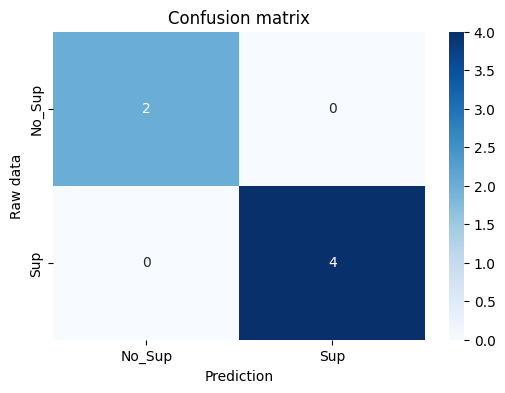

In [134]:

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['No_Sup','Sup'], yticklabels=['No_Sup','Sup'])
plt.xlabel("Prediction")
plt.ylabel("Raw data")
plt.title("Confusion matrix")
plt.show()


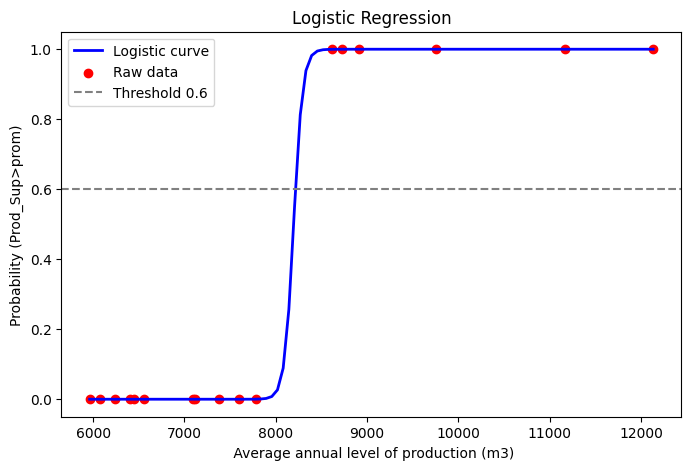

In [151]:
# Visualizar la curva de regresión
##################################

# Probabilidades predichas para todo el rango de valores de petróleo

X_range = np.linspace(ppp['Petroleo(m3)'].min(), ppp['Petroleo(m3)'].max(), 100).reshape(-1,1)
y_prob = modelo_LR.predict_proba(X_range)[:,1]  # Probabilidad de clase 1

plt.figure(figsize=(8,5))
plt.plot(X_range, y_prob, color="blue", linewidth=2, label="Logistic curve")
plt.scatter(x_pet,y_pet,color="red", label="Raw data")
plt.axhline(0.6, color="gray", linestyle="--", label="Threshold 0.6")
plt.xlabel(" Average annual level of production (m3)")
plt.ylabel("Probability (Prod_Sup>prom)")
plt.title("Logistic Regression")
plt.legend()
plt.show()

import warnings
warnings.filterwarnings("ignore", category=UserWarning)


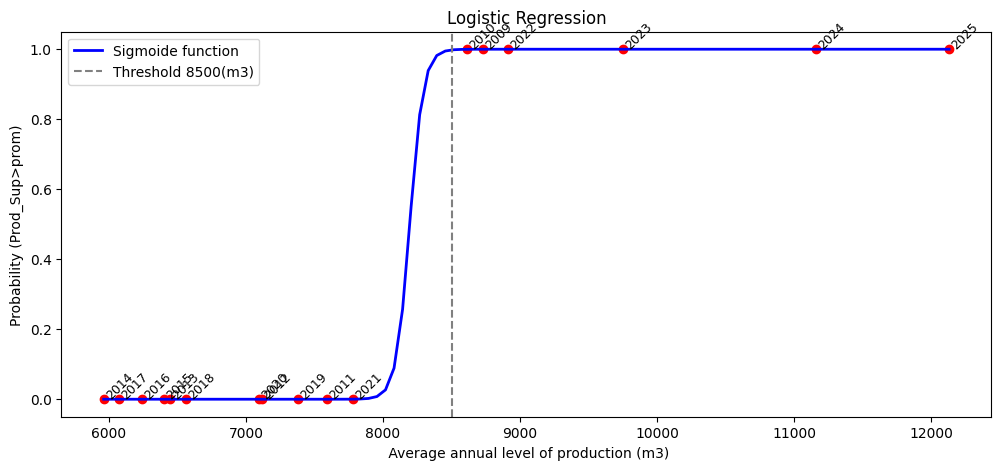

In [300]:

X_range = np.linspace(ppp['Petroleo(m3)'].min(), ppp['Petroleo(m3)'].max(), 100).reshape(-1,1)
y_prob = modelo_LR.predict_proba(X_range)[:,1]


plt.figure(figsize=(12,5))
plt.plot(X_range, y_prob, color="blue", linewidth=2, label="Sigmoide function")

for i, row in ppp.iterrows():
    plt.scatter(row['Petroleo(m3)'], row['Prod_Sup'], color="red")
    plt.text(row['Petroleo(m3)'], row['Prod_Sup']+0.001, str(row['anio'].astype(int)), fontsize=9, rotation=45)

#plt.axhline(0.5, color="gray", linestyle="--", label="Umbral 0.5")
plt.axvline(8500, color="gray", linestyle="--", label="Threshold 8500(m3)")
plt.xlabel(" Average annual level of production (m3)")
plt.ylabel("Probability (Prod_Sup>prom)")
plt.title("Logistic Regression")
plt.legend()
plt.show()

In [301]:
# Sigmoide parameters

beta0 = modelo_LR.intercept_[0]
beta1 = modelo_LR.coef_[0][0]

print("Intercept(β0):", beta0)
print("Coeficient (β1):", beta1)

Intercept(β0): -166.3638824286741
Coeficient (β1): 0.02030001151489449


In [302]:
# Sigmoide equation
def sigmoid(x):
    return 1 / (1 + np.exp(-(beta0 + beta1*x)))

valor = 8500
print("Probabilidad para x=8000:", round(sigmoid(valor),2))

Probabilidad para x=8000: 1.0


In [303]:

# Case 2:  Logistic regression with two variables: x1,x2 #
##########################################################

In [304]:

X = ppp[['anio','Petroleo(m3)']]
y = ppp['Prod_Sup']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
modelo2= LogisticRegression( multi_class='ovr',max_iter=1000, solver='lbfgs')
modelo2.fit(X_train, y_train)


y_pred = modelo2.predict(X_test)

y_pred

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


array([1, 1, 0, 1, 0, 1])

Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



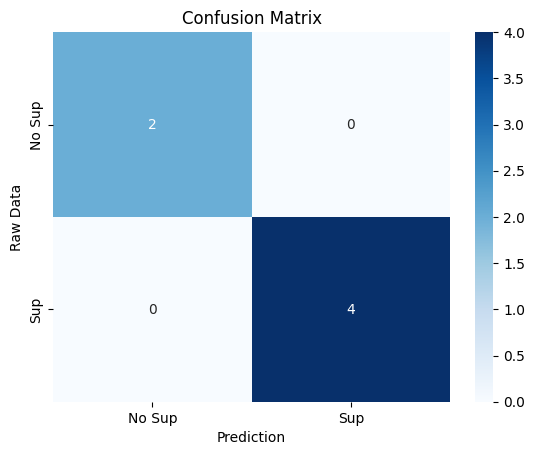

In [305]:

print("Reporte de clasificación:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['No Sup','Sup'], yticklabels=['No Sup','Sup'])
plt.xlabel("Prediction")
plt.ylabel("Raw Data")
plt.title("Confusion Matrix")
plt.show()


In [306]:
modelo2.coef_

array([[-0.06174037,  0.01495156]])

In [307]:

print("magnitudes X:", X.columns.tolist())
print("Coeficients:", modelo2.coef_)

magnitudes X: ['anio', 'Petroleo(m3)']
Coeficients: [[-0.06174037  0.01495156]]


In [308]:

# Parameters
beta0 = modelo2.intercept_[0]
beta1 = modelo2.coef_[0][0] 
beta2= modelo2.coef_[0][1] 

print("Intercept (β0):", beta0)
print("Coeficients (β1,β2):", beta1,beta2)

Intercept (β0): -3.1012850830225705e-05
Coeficients (β1,β2): -0.061740372745549395 0.014951557286812987


In [309]:
# Sigmoide function
def sigmoid(x1,x2):
    return 1 / (1 + np.exp(-(beta0 + beta1*x1+ beta2*x2)))


Prod_Petroleo = 8500
Anio_Prod= 2022
print("Probability:", round(sigmoid(Anio_Prod,Prod_Petroleo)*100, 2))


Probability: 90.46


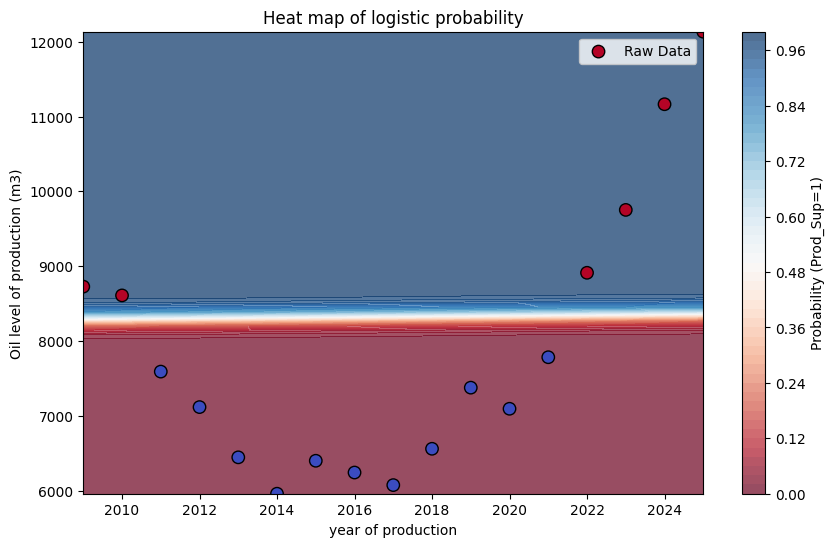

In [310]:
# Crear malla de valores (anio vs petróleo)
anio_range = np.linspace(ppp['anio'].min(), ppp['anio'].max(), 100)
petro_range = np.linspace(ppp['Petroleo(m3)'].min(), ppp['Petroleo(m3)'].max(), 100)
A, P = np.meshgrid(anio_range, petro_range)

# Calcular probabilidades en toda la malla
Z = sigmoid(A, P)

# Graficar mapa de calor
plt.figure(figsize=(10,6))
plt.contourf(A, P, Z, levels=50, cmap="RdBu", alpha=0.7)
plt.colorbar(label="Probability (Prod_Sup=1)")

# Añadir puntos reales
plt.scatter(ppp['anio'], ppp['Petroleo(m3)'], c=ppp['Prod_Sup'], cmap="coolwarm", edgecolor="k", s=80, label="Raw Data")

plt.xlabel("year of production")
plt.ylabel("Oil level of production (m3)")
plt.title("Heat map of logistic probability")
plt.legend()
plt.show()


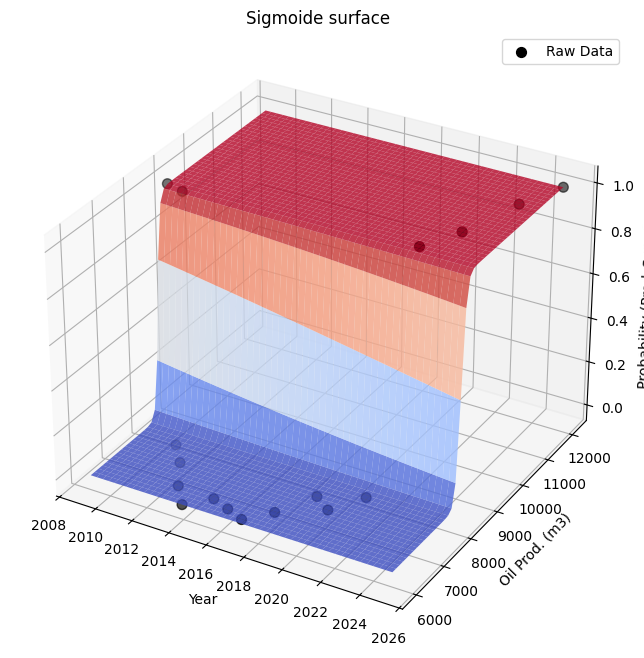

In [359]:

# 3D logistic surface

anio_range = np.linspace(ppp['anio'].min(), ppp['anio'].max(), 50)
petro_range = np.linspace(ppp['Petroleo(m3)'].min(), ppp['Petroleo(m3)'].max(), 50)
A, P = np.meshgrid(anio_range, petro_range)


Z = sigmoid(A, P)


fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(A, P, Z, cmap="coolwarm", alpha=0.8)


ax.scatter(ppp['anio'], ppp['Petroleo(m3)'], ppp['Prod_Sup'], color="black", s=50, label="Raw Data")

ax.set_xlabel("Year")
ax.set_ylabel("Oil Prod. (m3)")
ax.set_zlabel("Probability (Prod_Sup>Prom)")
ax.set_title("Sigmoide surface")
ax.legend()
plt.show()


In [360]:

# Case 3:  Multimodal logistic regression 
##########################################
ic_agua=pd.read_csv(r"C:\Users\Usuario\Documents\Python Scripts\Ind_Contaminante_Agua.csv",delimiter=',')
ic_agua=pd.DataFrame(ic_agua)
ic_agua

,sitios,fecha,hidr_deriv_petr_ug_l,cr_total_mg_l,cd_total_mg_l,clorofila_a_ug_l,microcistina_ug_l,ica,calidad_de_agua,Nivel_Deterioro,mes
0,Canal Villanueva y Río Luján,22/2/2023,0.1,0.005,0.001,0.87,0.15,53.0,Muy deteriorada,Medio,2
1,Río Lujan y Arroyo Caraguatá,22/2/2023,0.1,0.005,0.001,10.61,0.21,39.0,Extremadamente deteriorada,Alto,2
2,Canal Aliviador y Río Lujan,22/2/2023,0.1,0.005,0.001,16.87,2.98,35.0,Extremadamente deteriorada,Alto,2
3,Río Carapachay y Arroyo Gallo Fiambre,22/2/2023,0.1,0.005,0.001,10.89,0.15,37.0,Extremadamente deteriorada,Alto,2
4,Río Reconquista y Río Lujan,22/2/2023,0.1,0.005,0.001,8.57,0.15,34.0,Extremadamente deteriorada,Alto,2
...,...,...,...,...,...,...,...,...,...,...,...
164,Balneario Palo Blanco,14/11/2023,0.1,0.005,0.001,10.00,0.69,37.0,Extremadamente deteriorada,Alto,11
165,Diagonal 66 (descarga cloaca),14/11/2023,0.1,0.005,0.001,10.00,1.18,37.0,Extremadamente deteriorada,Alto,11
166,Playa La Bagliardi,14/11/2023,0.1,0.005,0.001,10.00,0.15,25.0,Extremadamente deteriorada,Alto,11
167,Balneario Municipal,14/11/2023,0.1,0.005,0.001,10.00,0.15,41.0,Extremadamente deteriorada,Alto,11


In [361]:
ic_agua.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sitios                169 non-null    object 
 1   fecha                 169 non-null    object 
 2   hidr_deriv_petr_ug_l  169 non-null    float64
 3   cr_total_mg_l         169 non-null    float64
 4   cd_total_mg_l         169 non-null    float64
 5   clorofila_a_ug_l      169 non-null    float64
 6   microcistina_ug_l     169 non-null    float64
 7   ica                   169 non-null    float64
 8   calidad_de_agua       154 non-null    object 
 9   Nivel_Deterioro       169 non-null    object 
 10  mes                   169 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 14.6+ KB


In [362]:
ic_agua['Nivel_Deterioro'].value_counts()

Nivel_Deterioro
Alto        127
Sin_Dato     32
Medio        10
Name: count, dtype: int64

In [363]:
x_rlm=ic_agua.select_dtypes(include='float')
y_rlm=ic_agua['Nivel_Deterioro']

In [364]:


xlm_train, xlm_test, ylm_train, ylm_test = train_test_split(x_rlm, y_rlm, test_size=0.3, random_state=42)

print("x_train shape:",xlm_train.shape)
print("y_train shape:",ylm_train.shape)
print("x_test shape:",xlm_test.shape)
print("y_test shape:",ylm_test.shape)

xlm_train

x_train shape: (118, 6)
y_train shape: (118,)
x_test shape: (51, 6)
y_test shape: (51,)


,hidr_deriv_petr_ug_l,cr_total_mg_l,cd_total_mg_l,clorofila_a_ug_l,microcistina_ug_l,ica
160,0.1,0.005,0.001,10.00,0.15,39.0
96,0.1,0.005,0.001,0.94,0.15,40.0
11,0.1,0.005,0.001,11.81,0.15,37.0
67,0.1,0.005,1.000,0.10,0.15,35.0
132,0.1,0.000,0.001,30.00,0.15,30.0
...,...,...,...,...,...,...
71,0.1,0.005,1.000,5.91,0.15,28.0
106,0.1,0.005,0.001,3.48,0.15,38.0
14,0.1,0.005,0.001,10.00,0.27,34.0
92,0.1,0.005,0.001,0.59,0.15,59.0


In [365]:

model_lm = OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='lbfgs'))
model_lm.fit(xlm_train, ylm_train)

,estimator,LogisticRegre...max_iter=1000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


In [366]:

y_pred_lm=model_lm.predict(xlm_test)

In [367]:

resultado_rlm=pd.DataFrame({"Valor_Real":ylm_test,"Valor_Pred":y_pred_lm})
resultado_rlm

,Valor_Real,Valor_Pred
138,Alto,Alto
30,Sin_Dato,Sin_Dato
119,Alto,Alto
29,Sin_Dato,Sin_Dato
143,Alto,Alto
162,Medio,Medio
165,Alto,Alto
51,Alto,Alto
105,Alto,Alto
60,Alto,Alto


In [368]:

labels= sorted(ylm_test.unique())
labels

['Alto', 'Medio', 'Sin_Dato']

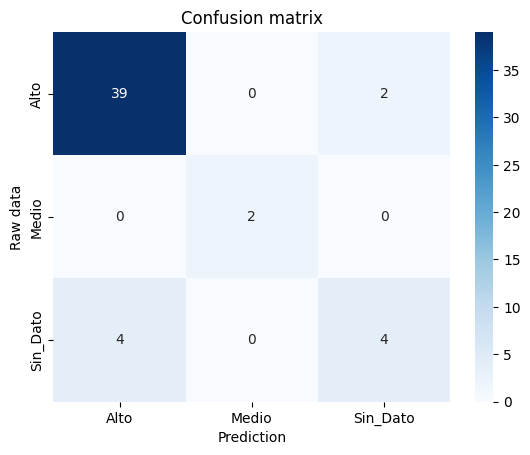

In [369]:

cm = confusion_matrix(ylm_test, y_pred_lm,labels=labels)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Alto', 'Medio', 'Sin_Dato'], yticklabels=['Alto', 'Medio', 'Sin_Dato'])
plt.xlabel("Prediction")
plt.ylabel("Raw data")
plt.title("Confusion matrix")
plt.show()


In [370]:
# Metrics
print(classification_report(ylm_test, y_pred_lm))

              precision    recall  f1-score   support

        Alto       0.91      0.95      0.93        41
       Medio       1.00      1.00      1.00         2
    Sin_Dato       0.67      0.50      0.57         8

    accuracy                           0.88        51
   macro avg       0.86      0.82      0.83        51
weighted avg       0.87      0.88      0.88        51



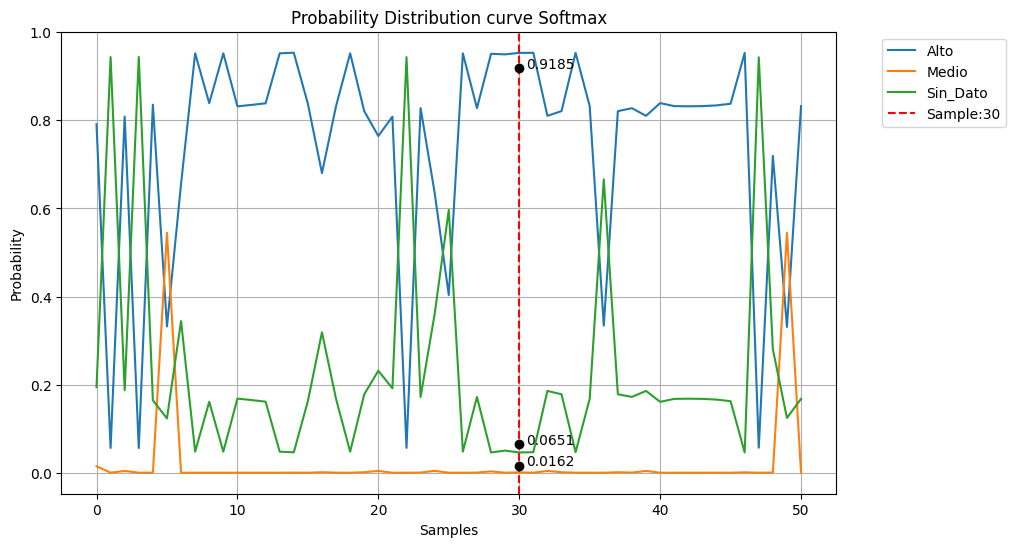

In [371]:

probs = model_lm.predict_proba(xlm_test) 

subset_probs = probs[:51, :]

plt.figure(figsize=(10,6))
for i, label in enumerate(labels):
    plt.plot(subset_probs[:, i], label=label)

plt.axvline(x=30, color='red', linestyle='--', linewidth=1.5, label="Sample:30")

points = [(30, 0.9185), (30, 0.0162), (30, 0.0651)]


for x, y in points:
    plt.scatter(x, y, color='black', zorder=5)  # punto negro
    plt.text(x+0.5, y, f"{y:.4f}", fontsize=10, color='black')  # etiqueta con valor

plt.title("Probability Distribution curve Softmax")
plt.xlabel("Samples")
plt.ylabel("Probability")
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1))


plt.grid(True)
plt.show()



In [372]:

probs = model_lm.predict_proba(xlm_test) 


df_probs = pd.DataFrame(probs, columns=labels)


print(df_probs.head(10))


       Alto         Medio  Sin_Dato
0  0.791357  1.455484e-02  0.194088
1  0.056265  8.761319e-05  0.943648
2  0.808507  4.041809e-03  0.187451
3  0.056016  8.980471e-05  0.943894
4  0.835488  2.402607e-05  0.164488
5  0.332074  5.446327e-01  0.123293
6  0.655590  8.600548e-05  0.344324
7  0.952170  6.108887e-06  0.047824
8  0.838939  1.578338e-07  0.161061
9  0.952181  6.098991e-06  0.047812


In [373]:

muestra_30 = df_probs.iloc[30]

print("Probability of sample 30:")
print(muestra_30)

#Alto:0.9185, Medio:0.0162, Sin_Dato:0.0651

Probability of sample 30:
Alto        0.953144
Medio       0.000882
Sin_Dato    0.045974
Name: 30, dtype: float64


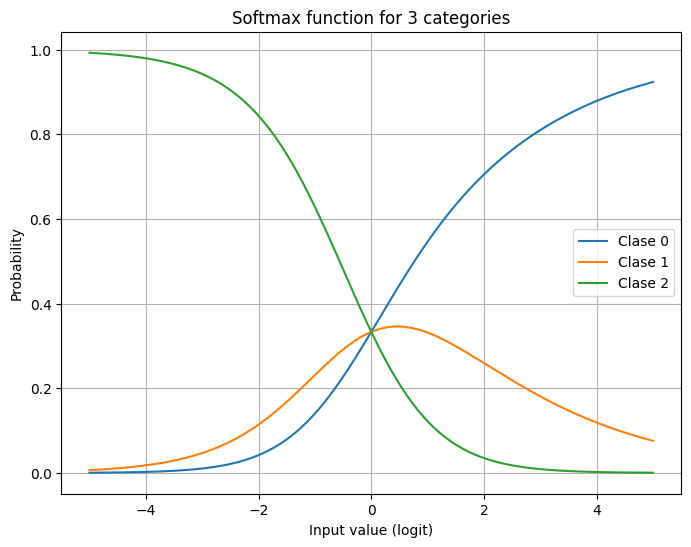

In [374]:
# Multiclass logistic regression (Simulation values)
#####################################################
# softmax function
def softmax(z):
    exp_z = np.exp(z - np.max(z))  
    return exp_z / exp_z.sum(axis=0)

x = np.linspace(-5, 5, 200)


logits = np.vstack([x, 0.5*x, -0.5*x])


probs = softmax(logits)


plt.figure(figsize=(8,6))
for i in range(probs.shape[0]):
    plt.plot(x, probs[i], label=f'Clase {i}')

plt.title("Softmax function for 3 categories")
plt.xlabel("Input value (logit)")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()